In [1]:
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
35,5.0,3.2,1.2,0.2,0
27,5.2,3.5,1.5,0.2,0
21,5.1,3.7,1.5,0.4,0
128,6.4,2.8,5.6,2.1,2
0,5.1,3.5,1.4,0.2,0
73,6.1,2.8,4.7,1.2,1
58,6.6,2.9,4.6,1.3,1
123,6.3,2.7,4.9,1.8,2
19,5.1,3.8,1.5,0.3,0
76,6.8,2.8,4.8,1.4,1


In [8]:
df = df[['sepal_length','petal_length','species']]

In [9]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [10]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [12]:
clf = LogisticRegression(multi_class='multinomial') # for softmax regression we use multinomial

In [13]:
clf.fit(X_train,y_train)

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [14]:
y_pred = clf.predict(X_test)

In [15]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [17]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [18]:
# prediction
query = np.array([[3.4,2.7]])
clf.predict_proba(query) # probability for each class

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [19]:
clf.predict(query) # predicted class-> it will give the class with highest probability

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


NameError: name 'plt' is not defined

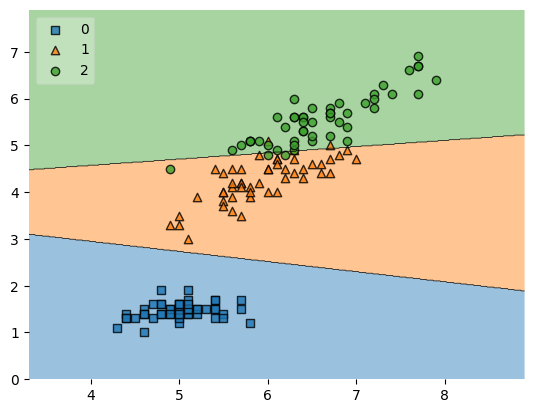

In [20]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf=clf, legend=2)

plt.xlabel('sepal_length[cm]')
plt.ylabel('petal_length[cm]')  
plt.title('Softmax Regression on Iris Dataset')